#**Customer Segmentation Analysis 📊**

This project focuses on understanding customer behavior and identifying meaningful customer segments using data analysis and machine learning techniques.

Customer segmentation helps businesses group customers based on similar characteristics, purchasing behavior, and spending patterns. By identifying these groups, businesses can gain better insights and make data-driven decisions.

In this project, K-Means Clustering, an unsupervised machine learning algorithm, is applied to segment customers based on their attributes and behavior.

#**Objectives**

- Analyze customer characteristics and purchasing behavior
- Perform data exploration and preprocessing
- Apply K-Means Clustering to identify customer segments
- Visualize different customer groups
- Generate insights from customer segmentation results

##**Importing Required Libraries**
The required Python libraries are imported for data manipulation, visualization, and machine learning model development.

In [ ]:
#Importing Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

import os
os.listdir('/content')

['.config', '.ipynb_checkpoints', 'Mall_Customers.csv']

#**Loading Dataset**
The dataset is loaded to analyze customer information and understand the available features.





The Mall Customers dataset contains customer demographic details and spending behavior, including:
- Customer ID
- Gender
- Age
- Annual Income
- Spending Score

In [ ]:
#Load Dataset

df = pd.read_csv('/content/Mall_Customers.csv')

#display first five rows

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


##**Dataset Overview**

The dataset is explored to understand its structure, features, and statistical information before applying machine learning techniques.

In [ ]:
#Dataset dimensions

df.shape

(200, 5)

In [ ]:
#Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
#Statiscal summary

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


##**Data Cleaning**
Data cleaning is performed to identify missing values and duplicate records to ensure the dataset is ready for analysis.

In [ ]:
#Check missing values

df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
#check duplicate records

df.duplicated().sum()

np.int64(0)

##**📊 Exploratory Data Analysis**

Exploratory Data Analysis (EDA) helps understand customer patterns, distributions, and relationships between different features using visualizations.

##**Age Distribution**

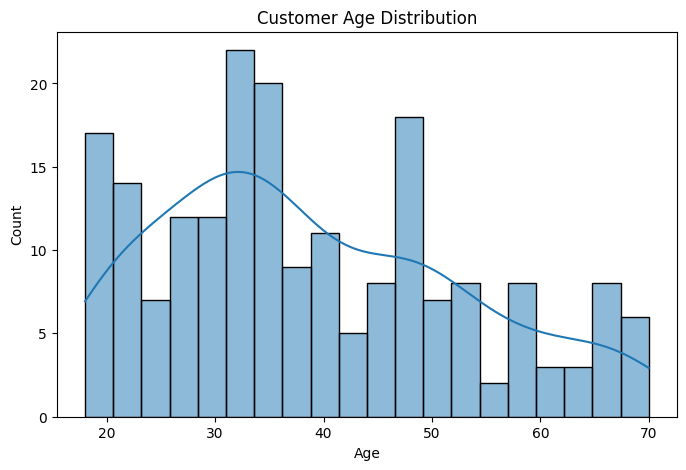

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=20,
    kde=True,
)

plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

##**Income vs Spending Score**

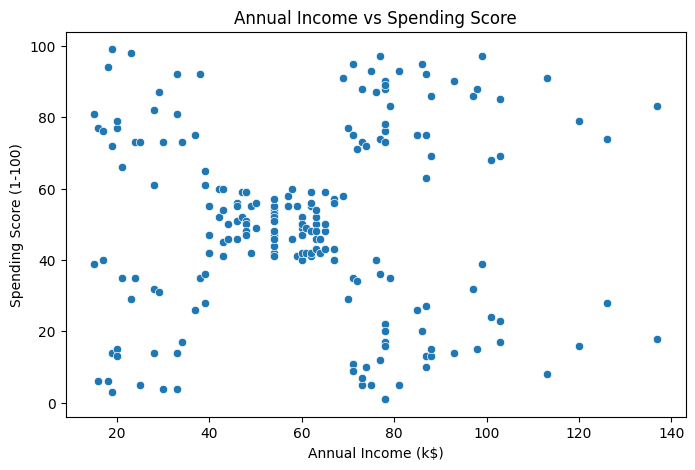

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data = df,
    x = 'Annual Income (k$)',
    y = 'Spending Score (1-100)'
)

plt.title('Annual Income vs Spending Score')

plt.show()

##**Feature Selection**
Relevant features are selected to identify customer groups based on their income and spending behavior.

**Selected features:**
- Annual Income (k$)
- Spending Score (1-100)

In [ ]:
#selecting features

X = df[
    [
        'Annual Income (k$)',
     'Spending Score (1-100)'
    ]
]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


##**Feature Scaling**

Feature scaling is applied to normalize the selected features and improve the performance of the clustering algorithm.

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

##**📈 Elbow Method**

The Elbow Method is used to determine the optimal number of clusters by analyzing the within-cluster variation.

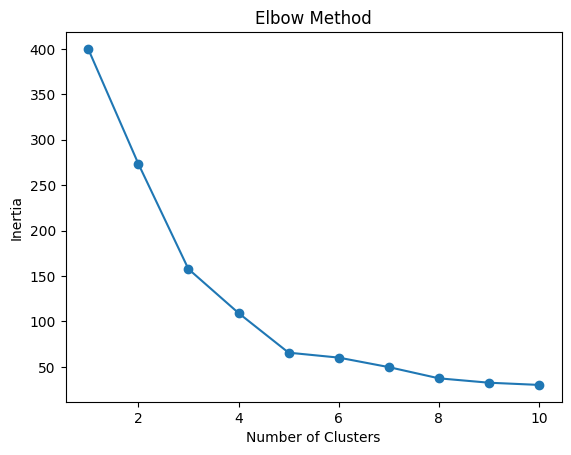

In [ ]:
inertia = []

for k in range(1,11):
  kmeans = KMeans(
      n_clusters=k,
      random_state=42
  )

  kmeans.fit(X_scaled)

  inertia.append(kmeans.inertia_)

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.show()

##**K-Means Clustering**

K-Means Clustering is applied to divide customers into different segments based on similarities in their income and spending behavior.

In [ ]:
#creating K-Means model

kmeans = KMeans(
    n_clusters = 5,
    random_state = 42
)

#Predict clusters

df['Clusters'] = kmeans.fit_predict(X_scaled)

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Clusters
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [ ]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Clusters'],
      dtype='object')

##**Customer Segment Visualization**

The customer clusters are visualized to understand different customer groups based on their spending patterns.

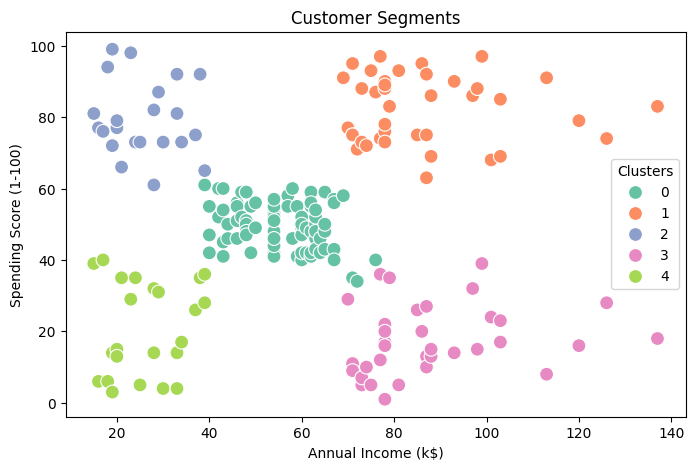

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data = df,
    x = 'Annual Income (k$)',
    y = 'Spending Score (1-100)',
    hue = 'Clusters',
    palette = 'Set2',
    s = 100
)

plt.title("Customer Segments")
plt.show()

##**Cluster Analysis**
The identified clusters represent different customer groups based on income and spending behavior.

These segments help businesses understand customer preferences and develop targeted marketing strategies.

In [ ]:
#Cluster summary

df.groupby('Clusters').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Clusters,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


##**Customer Segment Insights**

Based on the K-Means clustering results, customers can be grouped into different segments based on their income and spending behavior.

The identified segments represent different customer profiles such as:
- High-income high-spending customers
- High-income low-spending customers
- Low-income high-spending customers
- Budget-conscious customers

These insights can help businesses understand customer preferences and create targeted marketing strategies.

##**Conclusion**
This project demonstrates how machine learning techniques can be used for customer segmentation.

Using K-Means Clustering, customers were grouped into meaningful segments based on their purchasing behavior and spending patterns.

The insights obtained from customer segments can support personalized marketing strategies, customer analysis, and better business decision-making.

This project helped strengthen my understanding of data preprocessing, clustering algorithms, visualization, and analytical storytelling.

